### Task 1

In [ ]:
!mkdir -p /content/CSE425_project
!mkdir -p /content/CSE425_project/data

print("Project folder created at: /content/CSE425_project")

Project folder created at: /content/CSE425_project


In [ ]:
import os
PROJECT_ROOT = "/content/CSE425_project"
os.chdir(PROJECT_ROOT)
print("Current directory:", os.getcwd())

Current directory: /content/CSE425_project


In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets
!pip install -q librosa soundfile
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q tqdm jupyter
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:00


In [ ]:
MUSICCAPS_DIR = "/content/CSE425_project/data/raw/musiccaps"
os.makedirs(MUSICCAPS_DIR, exist_ok=True)

In [ ]:
!wget -O /content/CSE425_project/data/raw/musiccaps/musiccaps-public.csv \
https://huggingface.co/datasets/google/MusicCaps/resolve/main/musiccaps-public.csv

--2026-08-27 14:35:55--  https://huggingface.co/datasets/google/MusicCaps/resolve/main/musiccaps-public.csv
Resolving huggingface.co (huggingface.co)... 18.164.174.23, 18.164.174.55, 18.164.174.17, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/63d3fb232424c652f6f47b39/81b89084316f3d79cc16c3207c09625ac91860a34a98d5766ae0da80547e2caf?user_id=public&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27musiccaps-public.csv%3B+filename%3D%22musiccaps-public.csv%22%3B&response-content-type=text%2Fcsv&Expires=1787844955&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjNkM2ZiMjMyNDI0YzY1MmY2ZjQ3YjM5LzgxYjg5MDg0MzE2ZjNkNzljYzE2YzMyMDdjMDk2MjVhYzkxODYwYTM0YTk4ZDU3NjZhZTBkYTgwNTQ3ZTJjYWZcXD91c2VyX2lkPXB1YmxpYyZYLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomcmVzcG9u

In [ ]:
import pandas as pd

metadata_path = "/content/CSE425_project/data/raw/musiccaps/musiccaps-public.csv"
musiccaps_df = pd.read_csv(metadata_path)

print("Number of samples:", len(musiccaps_df))

Number of samples: 5521


In [ ]:
musiccaps_df.head()

,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False


In [ ]:
musiccaps_df["end_s"].sub(musiccaps_df["start_s"]).value_counts()

,count
10,5521


In [ ]:
for i in range(5):
    print(f"\n--- Sample {i} ---")
    print("ID:", musiccaps_df.loc[i, "ytid"])
    print("Time:", musiccaps_df.loc[i, "start_s"], "→", musiccaps_df.loc[i, "end_s"])
    print("Caption:", musiccaps_df.loc[i, "caption"])
    print("Aspects:", musiccaps_df.loc[i, "aspect_list"])


--- Sample 0 ---
ID: -0Gj8-vB1q4
Time: 30 → 40
Caption: The low quality recording features a ballad song that contains sustained strings, mellow piano melody and soft female vocal singing over it. It sounds sad and soulful, like something you would hear at Sunday services.
Aspects: ['low quality', 'sustained strings melody', 'soft female vocal', 'mellow piano melody', 'sad', 'soulful', 'ballad']

--- Sample 1 ---
ID: -0SdAVK79lg
Time: 30 → 40
Caption: This song features an electric guitar as the main instrument. The guitar plays a descending run in the beginning then plays an arpeggiated chord followed by a double stop hammer on to a higher note and a descending slide followed by a descending chord run. The percussion plays a simple beat using rim shots. The percussion plays in common time. The bass plays only one note on the first count of each bar. The piano plays backing chords. There are no voices in this song. The mood of this song is relaxing. This song can be played in a coffee

In [ ]:
print(musiccaps_df.shape)
print(musiccaps_df.columns)

(5521, 9)
Index(['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list',
       'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval'],
      dtype='object')


In [ ]:
print(musiccaps_df[["ytid", "start_s", "end_s"]].head(20).to_string(index=False))

       ytid  start_s  end_s
-0Gj8-vB1q4       30     40
-0SdAVK79lg       30     40
-0vPFx-wRRI       30     40
-0xzrMun0Rs       30     40
-1LrH01Ei1w       30     40
-1OlgJWehn8       30     40
-1UWSisR2zo       30     40
-3Kv4fdm7Uk       30     40
-4NLarMj4xU       30     40
-4SYC2YgzL8       30     40
-5FoeegAgvU      230    240
-5f6hjZf9Yw       30     40
-5xOcMJpTUk       70     80
-6HBGg1cAI0       30     40
-6QGvxvaTkI      280    290
-6pcgdLfb_A      110    120
-7B9tPuIP-w      450    460
-7wUQP6G5EQ       30     40
-88me9bBzrk       30     40
-8C-gydUbR8       30     40


In [ ]:
print(
    musiccaps_df[["start_s", "end_s"]]
    .drop_duplicates()
    .head(20)
)

    start_s  end_s
0        30     40
10      230    240
12       70     80
14      280    290
15      110    120
16      450    460
22      410    420
24        0     10
26      290    300
27       40     50
28       50     60
29      260    270
30      190    200
31       90    100
34      330    340
44       60     70
46      520    530
47       21     31
51      350    360
52      360    370


In [ ]:
print("Unique start times:", musiccaps_df["start_s"].nunique())
print("Unique end times:", musiccaps_df["end_s"].nunique())

Unique start times: 79
Unique end times: 79


In [ ]:
!pip install -q yt-dlp
!apt-get -qq update
!apt-get -qq install ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.4 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# Create project file structure
PROJECT_ROOT = '/content/CSE425_project'

AUDIO_DIR = f'{PROJECT_ROOT}/data/raw/musiccaps/audio'
CSV_PATH = f'{PROJECT_ROOT}/data/raw/musiccaps/musiccaps-public.csv'

directories = {

    'data_processed': f'{PROJECT_ROOT}/data/processed',
    'data_processed_graphs': f'{PROJECT_ROOT}/data/processed/graphs',
    'data_processed_melspec': f'{PROJECT_ROOT}/data/processed/mel-spec',
    'data_processed_bert': f'{PROJECT_ROOT}/data/processed/bert_caches',
    'data_splits': f'{PROJECT_ROOT}/data/splits',
    'results': f'{PROJECT_ROOT}/results',
    'results_plots': f'{PROJECT_ROOT}/results/plots',
    'results_metrics': f'{PROJECT_ROOT}/results/metrics',
    'results_retrieval': f'{PROJECT_ROOT}/results/retrieval_examples',
    'notebooks': f'{PROJECT_ROOT}/notebooks',
    'src': f'{PROJECT_ROOT}/src',
    'report': f'{PROJECT_ROOT}/report',
}

for name, path in directories.items():
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/CSE425_project/data/processed
Created: /content/CSE425_project/data/processed/graphs
Created: /content/CSE425_project/data/processed/mel-spec
Created: /content/CSE425_project/data/processed/bert_caches
Created: /content/CSE425_project/data/splits
Created: /content/CSE425_project/results
Created: /content/CSE425_project/results/plots
Created: /content/CSE425_project/results/metrics
Created: /content/CSE425_project/results/retrieval_examples
Created: /content/CSE425_project/notebooks
Created: /content/CSE425_project/src
Created: /content/CSE425_project/report


In [ ]:
# Import Libraries
import ast
from collections import Counter
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Build Tag Vocabulary from your MusicCaps data
def build_tag_vocabulary(df, top_k=50):
    all_aspects = []
    for aspect_str in df['aspect_list']:
        try:
            aspects = ast.literal_eval(aspect_str) if isinstance(aspect_str, str) else aspect_str
        except (ValueError, SyntaxError):
            aspects = str(aspect_str).split(',')
        all_aspects.extend([a.strip().lower() for a in aspects])

    tag_counts = Counter(all_aspects)
    top_tags = [tag for tag, _ in tag_counts.most_common(top_k)]

    print(f"Built vocabulary of {len(top_tags)} tags from {len(all_aspects)} total aspect mentions")
    print(f"Top 10 tags: {top_tags[:10]}")
    print(f"Tag frequency range: {tag_counts.most_common(1)[0][1]} to {tag_counts.most_common()[-1][1]}")

    return top_tags

TAG_VOCAB = build_tag_vocabulary(musiccaps_df, top_k=50)
print(f"\nFull tag vocabulary ({len(TAG_VOCAB)} tags):")
print(TAG_VOCAB)

Built vocabulary of 50 tags from 58901 total aspect mentions
Top 10 tags: ['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording', 'live performance', 'slow tempo']
Tag frequency range: 1220 to 1

Full tag vocabulary (50 tags):
['low quality', 'instrumental', 'emotional', 'noisy', 'passionate', 'medium tempo', 'energetic', 'amateur recording', 'live performance', 'slow tempo', 'acoustic drums', 'fast tempo', 'mono', 'groovy', 'bass guitar', 'electric guitar', 'acoustic guitar', 'instrumental music', 'uptempo', 'piano', 'punchy kick', 'poor audio quality', 'punchy snare', 'groovy bass', 'happy', 'male voice', 'moderate tempo', 'e-bass', 'shimmering hi hats', 'male vocal', 'rock', 'percussion', 'no voices', 'youthful', 'pop', 'male singer', 'spirited', 'romantic', 'electronic drums', 'exciting', 'upbeat', 'bass', 'loud', 'mellow', 'keyboard harmony', 'fun', 'cheerful', 'easygoing', 'flat male vocal', 'e-guitar']


In [ ]:
# Convert aspect_list to a multi-hot label vector
def caption_to_multihot(aspect_str, tag_vocab):
    try:
        aspects = ast.literal_eval(aspect_str) if isinstance(aspect_str, str) else aspect_str
    except (ValueError, SyntaxError):
        aspects = str(aspect_str).split(',')
    aspects = set(a.strip().lower() for a in aspects)

    return np.array([1.0 if tag in aspects else 0.0 for tag in tag_vocab])

print("\nConverting aspect_lists to multi-hot labels...")
musiccaps_df['multihot_labels'] = musiccaps_df['aspect_list'].apply(
    lambda x: caption_to_multihot(x, TAG_VOCAB)
)

print(f"Multi-hot labels created with shape: {musiccaps_df['multihot_labels'].iloc[0].shape}")

label_counts = np.sum(np.vstack(musiccaps_df['multihot_labels'].values), axis=0)
print(f"\nLabel frequency (top 10):")
for idx in np.argsort(label_counts)[-10:][::-1]:
    print(f"   {TAG_VOCAB[idx]}: {label_counts[idx]:.0f} clips")


Converting aspect_lists to multi-hot labels...
Multi-hot labels created with shape: (50,)

Label frequency (top 10):
   low quality: 1217 clips
   instrumental: 907 clips
   noisy: 626 clips
   emotional: 620 clips
   medium tempo: 595 clips
   energetic: 593 clips
   passionate: 592 clips
   amateur recording: 515 clips
   slow tempo: 473 clips
   live performance: 468 clips


In [ ]:
# Prepare Data for BERT Multi-label Classification
# Input: caption text → Output: multi-hot tags
def prepare_data_for_bert(df):
    texts = df['caption'].tolist()
    labels = np.vstack(df['multihot_labels'].values).astype(np.float32)

    return texts, labels

texts, labels = prepare_data_for_bert(musiccaps_df)
print(f"\nData prepared:")
print(f"   Texts: {len(texts)} samples")
print(f"   Labels: {labels.shape} (samples × tags)")


Data prepared:
   Texts: 5521 samples
   Labels: (5521, 50) (samples × tags)


In [ ]:
# Data Split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"\nData split:")
print(f"   Train: {len(X_train)} samples")
print(f"   Val: {len(X_val)} samples")
print(f"   Test: {len(X_test)} samples")


Data split:
   Train: 3864 samples
   Val: 828 samples
   Test: 829 samples


In [ ]:
# Create HuggingFace Dataset
def create_dataset(texts, labels):
    data_dict = {
        'text': texts,
        'labels': labels.tolist() if isinstance(labels, np.ndarray) else labels
    }
    return Dataset.from_dict(data_dict)

train_dataset = create_dataset(X_train, y_train)
val_dataset = create_dataset(X_val, y_val)
test_dataset = create_dataset(X_test, y_test)

datasets = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print("HuggingFace datasets created")

HuggingFace datasets created


In [ ]:
# Tokenization
print("\nTokenizing text with BERT...")
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_datasets = datasets.map(tokenize_function, batched=True)
print("Tokenization complete")


Tokenizing text with BERT...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3864 [00:00<?, ? examples/s]

Map:   0%|          | 0/828 [00:00<?, ? examples/s]

Map:   0%|          | 0/829 [00:00<?, ? examples/s]

Tokenization complete


In [ ]:
# Load Model for Multi-Label Classification
num_labels = len(TAG_VOCAB)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="multi_label_classification"  # Important!
)

print(f"Model loaded: {model_name}")
print(f"Number of tags: {num_labels}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Number of tags: 50


In [ ]:
# Define Metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = torch.sigmoid(torch.tensor(predictions)).numpy()

    predictions = (predictions > 0.5).astype(int)
    labels = labels.astype(int)

    f1 = f1_score(labels, predictions, average='micro', zero_division=0)
    accuracy = (predictions == labels).all(axis=1).mean()
    precision, recall, _, _ = precision_recall_fscore_support(
        labels, predictions, average='micro', zero_division=0
    )

    return {
        'accuracy': accuracy,
        'f1_micro': f1,
        'precision_micro': precision,
        'recall_micro': recall
    }

In [ ]:
# Training Parameters
training_args = TrainingArguments(
    output_dir=f'{PROJECT_ROOT}/results/task1_bert',  # Required: where to save
    num_train_epochs=3,                                # How many passes over data
    per_device_train_batch_size=16,                    # Batch size
    eval_strategy="epoch",                       # When to evaluate
    save_strategy="epoch",                             # When to save
    load_best_model_at_end=True,                       # Load best checkpoint
    metric_for_best_model="f1_micro",                  # What to optimize
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

In [ ]:
# Model Training
trainer.train()

print("\nTraining complete!")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,Precision Micro,Recall Micro
1,No log,0.160709,0.107488,0.190586,0.914815,0.106374
2,No log,0.129218,0.142512,0.378579,0.868624,0.242033
3,0.187253,0.120909,0.155797,0.459408,0.852804,0.314384


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!


In [ ]:
# Evaluate on Test Set
test_results = trainer.evaluate(tokenized_datasets['test'])

print("\nTest Results:")
for key, value in test_results.items():
    if 'eval_' in key:
        print(f"   {key.replace('eval_', '')}: {value:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1 Micro,Precision Micro,Recall Micro
0.187253,0.117625,3,0.177322,0.477650,0.840449,0.333631



Test Results:
   loss: 0.1176
   accuracy: 0.1773
   f1_micro: 0.4777
   precision_micro: 0.8404
   recall_micro: 0.3336


In [ ]:
# Per-Tag Analysis
def get_per_tag_metrics_simple(model, tokenizer, dataset, tag_vocab):
    predictions = trainer.predict(tokenized_datasets['test'])

    pred_logits = predictions.predictions
    labels = predictions.label_ids

    pred_probs = torch.sigmoid(torch.tensor(pred_logits)).numpy()
    predictions_binary = pred_probs > 0.5

    per_tag_metrics = []
    for i, tag in enumerate(tag_vocab):
        tp = np.sum((predictions_binary[:, i] == 1) & (labels[:, i] == 1))
        fp = np.sum((predictions_binary[:, i] == 1) & (labels[:, i] == 0))
        fn = np.sum((predictions_binary[:, i] == 0) & (labels[:, i] == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        per_tag_metrics.append({
            'tag': tag,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': tp + fn
        })

    return pd.DataFrame(per_tag_metrics)

per_tag_df = get_per_tag_metrics_simple(model, tokenizer, tokenized_datasets['test'], TAG_VOCAB)
print("\nTop 15 Tags by F1:")
print(per_tag_df.sort_values('f1', ascending=False).head(15).to_string())

print("\nBottom 15 Tags by F1:")
print(per_tag_df.sort_values('f1', ascending=True).head(15).to_string())


Top 15 Tags by F1:
                   tag  precision    recall        f1  support
0          low quality   0.932292  0.994444  0.962366      180
12                mono   1.000000  0.854167  0.921348       48
3                noisy   0.948718  0.880952  0.913580       84
17  instrumental music   0.785714  0.868421  0.825000       38
1         instrumental   0.868852  0.741259  0.800000      143
2            emotional   0.833333  0.568182  0.675676       88
27              e-bass   0.761905  0.592593  0.666667       27
20         punchy kick   0.782609  0.529412  0.631579       34
10      acoustic drums   0.818182  0.490909  0.613636       55
11          fast tempo   0.846154  0.478261  0.611111       69
14         bass guitar   0.809524  0.472222  0.596491       36
4           passionate   0.788462  0.465909  0.585714       88
22        punchy snare   0.652174  0.468750  0.545455       32
6            energetic   0.822222  0.406593  0.544118       91
29          male vocal   1.000000  

In [ ]:
# Save Model
model_path = f'{PROJECT_ROOT}/models/task1_bert_classifier'
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"\nModel saved to {model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to /content/CSE425_project/models/task1_bert_classifier


In [ ]:
# Save Metrics
metrics = {
    'task': 'Task 1: BERT Multi-Label Classifier',
    'num_tags': len(TAG_VOCAB),
    'tag_vocab': TAG_VOCAB[:20],  # Top 20 for brevity
    'test_results': {k.replace('eval_', ''): v for k, v in test_results.items() if 'eval_' in k},
    'per_tag_metrics': per_tag_df.to_dict('records')
}

import json
with open(f'{PROJECT_ROOT}/results/metrics/task1_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved to results/metrics/task1_metrics.json")

Metrics saved to results/metrics/task1_metrics.json


In [ ]:
# VISUALIZATIONS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import json
import os

plots_dir = f'{PROJECT_ROOT}/results/plots'
os.makedirs(plots_dir, exist_ok=True)

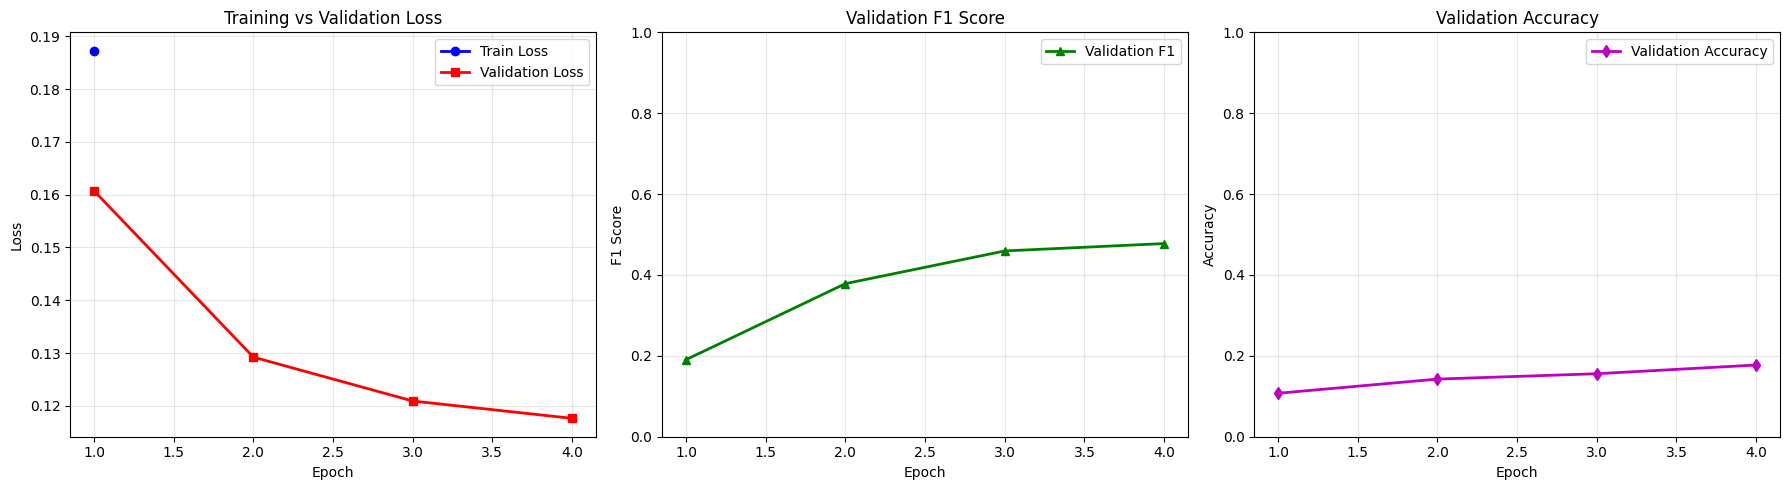

Training curves saved to: task1_training_curves.png


In [ ]:
# Training Curves (Loss & Metrics)

def plot_training_curves(trainer, plots_dir):
    history = trainer.state.log_history

    epochs = []
    train_loss = []
    eval_loss = []
    eval_f1 = []
    eval_acc = []

    for log in history:
        if 'loss' in log and 'epoch' in log:
            train_loss.append(log['loss'])
            epochs.append(log['epoch'])
        if 'eval_loss' in log:
            eval_loss.append(log['eval_loss'])
        if 'eval_f1_micro' in log:
            eval_f1.append(log['eval_f1_micro'])
        if 'eval_accuracy' in log:
            eval_acc.append(log['eval_accuracy'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if train_loss and eval_loss:
        axes[0].plot(range(1, len(train_loss)+1), train_loss, 'b-o', label='Train Loss', linewidth=2)
        axes[0].plot(range(1, len(eval_loss)+1), eval_loss, 'r-s', label='Validation Loss', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training vs Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

    if eval_f1:
        axes[1].plot(range(1, len(eval_f1)+1), eval_f1, 'g-^', label='Validation F1', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('F1 Score')
        axes[1].set_title('Validation F1 Score')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim([0, 1])

    if eval_acc:
        axes[2].plot(range(1, len(eval_acc)+1), eval_acc, 'm-d', label='Validation Accuracy', linewidth=2)
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Accuracy')
        axes[2].set_title('Validation Accuracy')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        axes[2].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(f'{plots_dir}/task1_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Training curves saved to: task1_training_curves.png")

plot_training_curves(trainer, plots_dir)

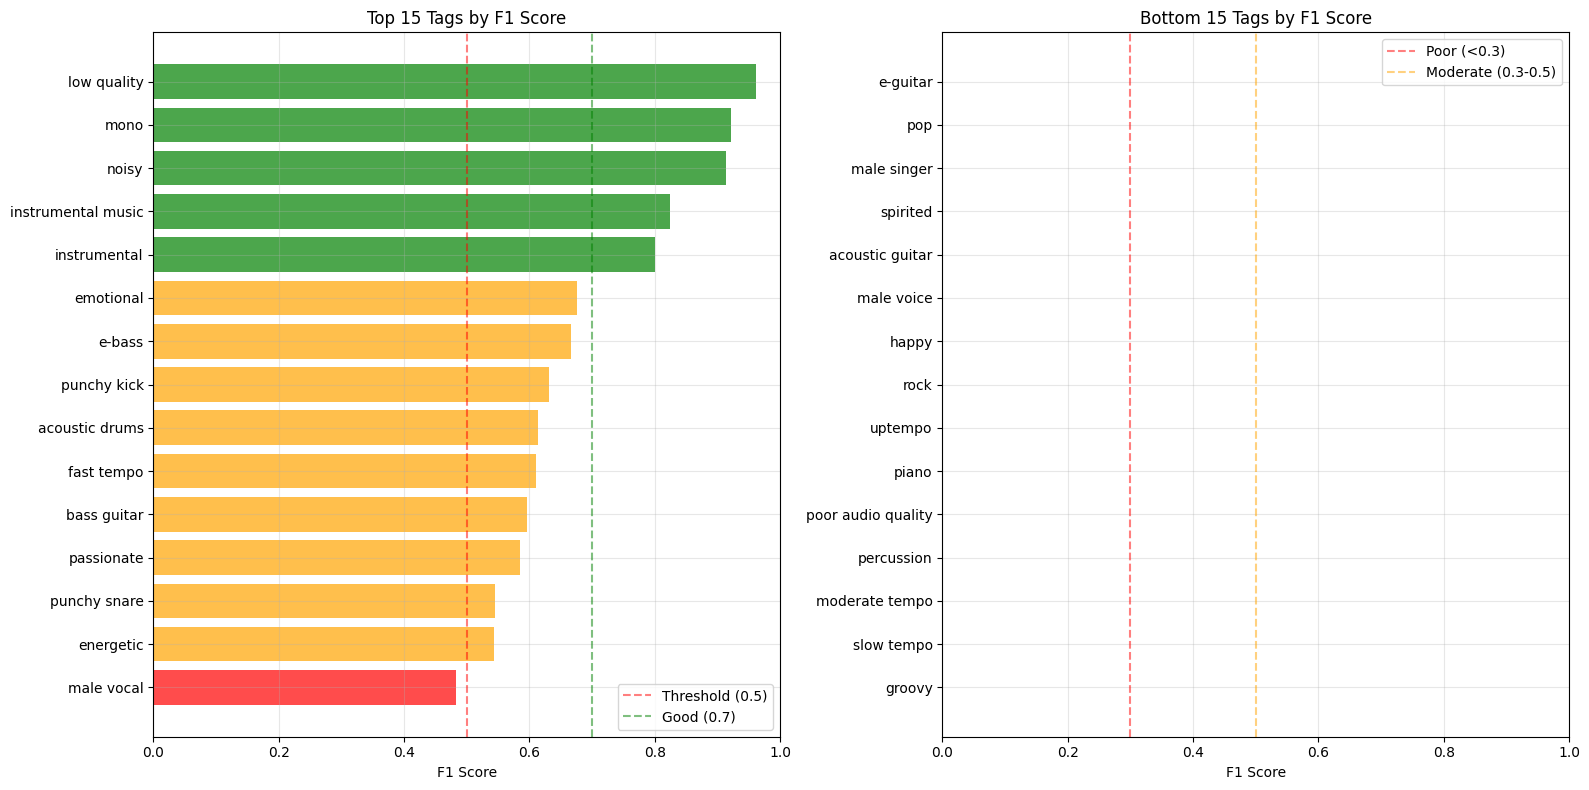

Per-tag performance saved to: task1_per_tag_performance.png


In [ ]:
# Per-Tag Performance Bar Chart

def plot_per_tag_performance(per_tag_df, plots_dir, top_k=20):

    sorted_df = per_tag_df.sort_values('f1', ascending=True)
    top_df = sorted_df.tail(top_k)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    colors = ['green' if f1 > 0.7 else 'orange' if f1 > 0.5 else 'red' for f1 in top_df['f1']]
    axes[0].barh(top_df['tag'], top_df['f1'], color=colors, alpha=0.7)
    axes[0].set_xlabel('F1 Score')
    axes[0].set_title(f'Top {top_k} Tags by F1 Score')
    axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold (0.5)')
    axes[0].axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Good (0.7)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, 1])

    bottom_df = sorted_df.head(top_k)
    colors = ['red' if f1 < 0.3 else 'orange' if f1 < 0.5 else 'green' for f1 in bottom_df['f1']]
    axes[1].barh(bottom_df['tag'], bottom_df['f1'], color=colors, alpha=0.7)
    axes[1].set_xlabel('F1 Score')
    axes[1].set_title(f'Bottom {top_k} Tags by F1 Score')
    axes[1].axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Poor (<0.3)')
    axes[1].axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate (0.3-0.5)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0, 1])

    plt.tight_layout()
    plt.savefig(f'{plots_dir}/task1_per_tag_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Per-tag performance saved to: task1_per_tag_performance.png")

plot_per_tag_performance(per_tag_df, plots_dir, top_k=15)

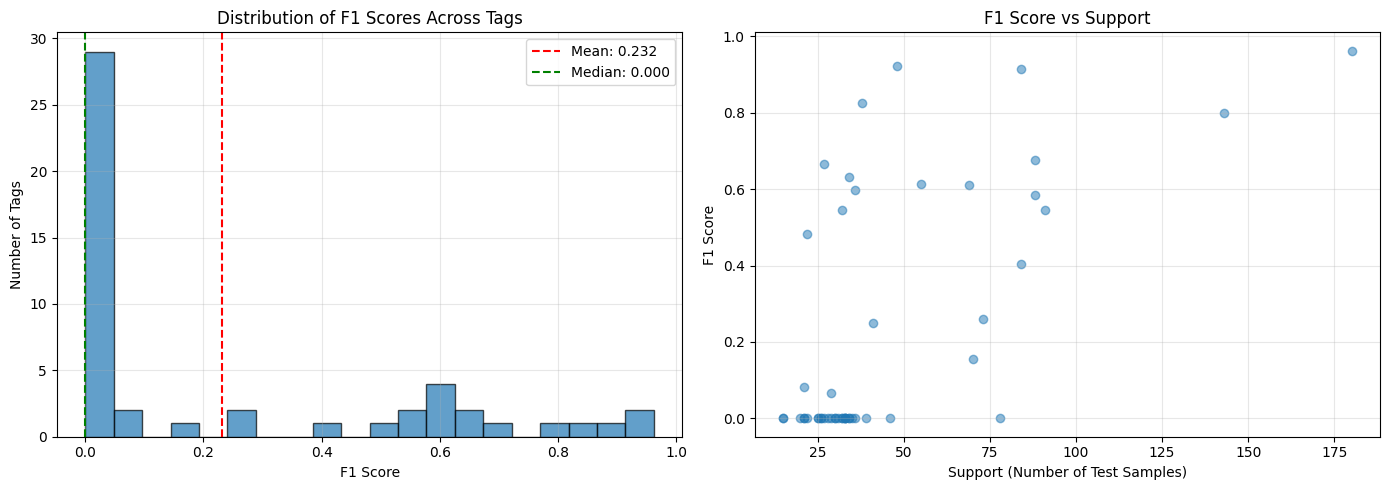

Tag analysis saved to: task1_tag_analysis.png


In [ ]:
# Tag Frequency Distribution

def plot_tag_frequency(per_tag_df, plots_dir):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(per_tag_df['f1'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('F1 Score')
    axes[0].set_ylabel('Number of Tags')
    axes[0].set_title('Distribution of F1 Scores Across Tags')
    axes[0].axvline(x=per_tag_df['f1'].mean(), color='red', linestyle='--',
                    label=f'Mean: {per_tag_df["f1"].mean():.3f}')
    axes[0].axvline(x=per_tag_df['f1'].median(), color='green', linestyle='--',
                    label=f'Median: {per_tag_df["f1"].median():.3f}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(per_tag_df['support'], per_tag_df['f1'], alpha=0.5)
    axes[1].set_xlabel('Support (Number of Test Samples)')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('F1 Score vs Support')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{plots_dir}/task1_tag_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Tag analysis saved to: task1_tag_analysis.png")

plot_tag_frequency(per_tag_df, plots_dir)


Top 15 Tags by F1:
               tag  precision   recall       f1  support  tp  fp  fn  tn
       low quality   0.932292 0.994444 0.962366      180 179  13   1 636
              mono   1.000000 0.854167 0.921348       48  41   0   7 781
             noisy   0.948718 0.880952 0.913580       84  74   4  10 741
instrumental music   0.785714 0.868421 0.825000       38  33   9   5 782
      instrumental   0.868852 0.741259 0.800000      143 106  16  37 670
         emotional   0.833333 0.568182 0.675676       88  50  10  38 731
            e-bass   0.761905 0.592593 0.666667       27  16   5  11 797
       punchy kick   0.782609 0.529412 0.631579       34  18   5  16 790
    acoustic drums   0.818182 0.490909 0.613636       55  27   6  28 768
        fast tempo   0.846154 0.478261 0.611111       69  33   6  36 754
       bass guitar   0.809524 0.472222 0.596491       36  17   4  19 789
        passionate   0.788462 0.465909 0.585714       88  41  11  47 730
      punchy snare   0.652174 0

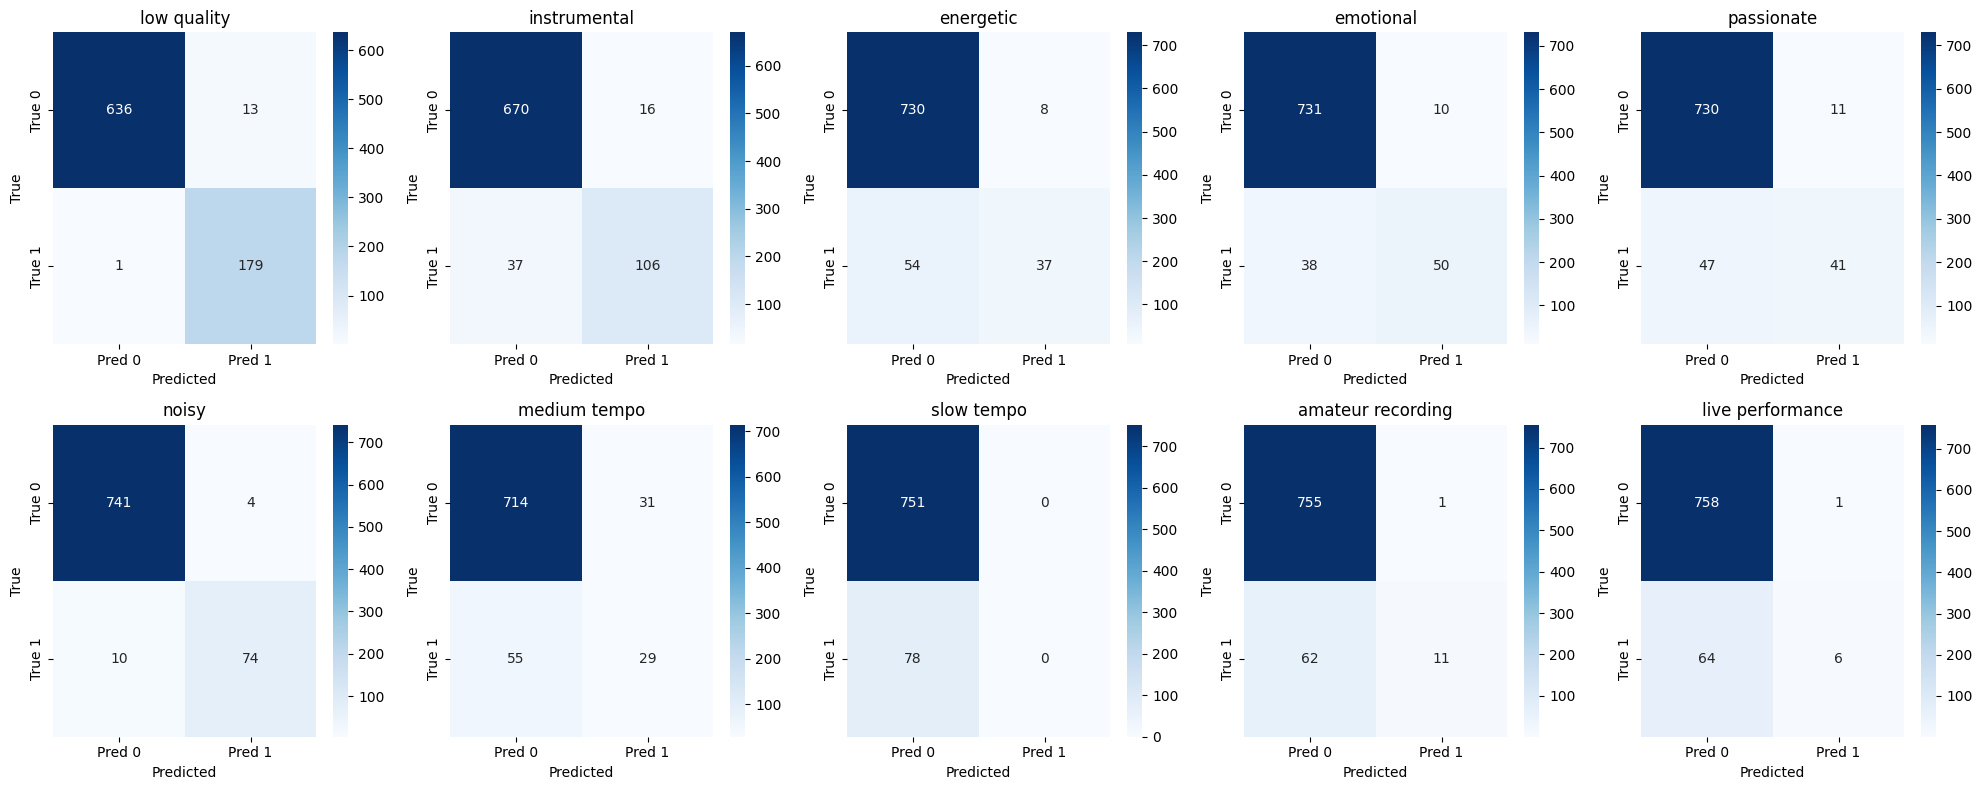


Per-tag metrics saved to: /content/CSE425_project/results/task1_bert/per_tag_metrics.csv

Summary Statistics:
Number of tags: 50
Average F1 across all tags: 0.2319
Tags with F1 > 0.5: 14/50
Tags with zero F1: 29/50
Tags with perfect F1 (1.0): 0/50


In [ ]:
# Per Tag Analysis
def get_per_tag_metrics(predictions_binary, labels, tag_vocab):
    per_tag_metrics = []

    for i, tag in enumerate(tag_vocab):
        tp = np.sum((predictions_binary[:, i] == 1) & (labels[:, i] == 1))
        fp = np.sum((predictions_binary[:, i] == 1) & (labels[:, i] == 0))
        fn = np.sum((predictions_binary[:, i] == 0) & (labels[:, i] == 1))
        tn = np.sum((predictions_binary[:, i] == 0) & (labels[:, i] == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        per_tag_metrics.append({
            'tag': tag,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': tp + fn,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        })

    return pd.DataFrame(per_tag_metrics)

def get_predictions_and_labels(model, tokenizer, dataset):
    predictions = trainer.predict(dataset)
    pred_logits = predictions.predictions
    labels = predictions.label_ids
    pred_probs = torch.sigmoid(torch.tensor(pred_logits)).numpy()
    predictions_binary = pred_probs > 0.5
    return predictions_binary, labels

predictions_binary, labels = get_predictions_and_labels(model, tokenizer, tokenized_datasets['test'])

per_tag_df = get_per_tag_metrics(predictions_binary, labels, TAG_VOCAB)

print("\nTop 15 Tags by F1:")
print(per_tag_df.sort_values('f1', ascending=False).head(15).to_string(index=False))

print("\nBottom 15 Tags by F1:")
print(per_tag_df.sort_values('f1', ascending=True).head(15).to_string(index=False))

def plot_confusion_matrix_from_predictions(predictions_binary, labels, tag_vocab, plots_dir, top_n=10):

    supports = labels.sum(axis=0)
    tag_support = pd.DataFrame({
        'tag': tag_vocab,
        'support': supports
    }).sort_values('support', ascending=False).head(top_n)

    top_tags = tag_support['tag'].tolist()
    top_indices = [tag_vocab.index(tag) for tag in top_tags]

    n_cols = 5
    n_rows = (top_n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
    axes = axes.flatten()

    for idx, (tag, tag_idx) in enumerate(zip(top_tags, top_indices)):
        if idx >= top_n:
            break

        pred_tag = predictions_binary[:, tag_idx]
        labels_tag = labels[:, tag_idx]

        cm = np.zeros((2, 2), dtype=int)
        for i in range(len(pred_tag)):
            cm[int(labels_tag[i])][int(pred_tag[i])] += 1

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   xticklabels=['Pred 0', 'Pred 1'],
                   yticklabels=['True 0', 'True 1'])
        axes[idx].set_title(f'{tag}')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')

    for idx in range(len(top_tags), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()

    os.makedirs(plots_dir, exist_ok=True)

    plot_path = os.path.join(plots_dir, f'confusion_matrix_top{top_n}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Confusion matrix saved to: {plot_path}")
    plt.show()

    return fig

plot_confusion_matrix_from_predictions(
    predictions_binary,
    labels,
    TAG_VOCAB,
    plots_dir=f'{PROJECT_ROOT}/plots',
    top_n=10
)

per_tag_df.to_csv(f'{PROJECT_ROOT}/results/task1_bert/per_tag_metrics.csv', index=False)
print(f"\nPer-tag metrics saved to: {PROJECT_ROOT}/results/task1_bert/per_tag_metrics.csv")

print(f"\nSummary Statistics:")
print(f"Number of tags: {len(per_tag_df)}")
print(f"Average F1 across all tags: {per_tag_df['f1'].mean():.4f}")
print(f"Tags with F1 > 0.5: {sum(per_tag_df['f1'] > 0.5)}/{len(per_tag_df)}")
print(f"Tags with zero F1: {sum(per_tag_df['f1'] == 0)}/{len(per_tag_df)}")
print(f"Tags with perfect F1 (1.0): {sum(per_tag_df['f1'] == 1.0)}/{len(per_tag_df)}")

Generating predictions for visualization...


Example predictions saved to: /content/CSE425_project/results/plots/task1_example_predictions.png


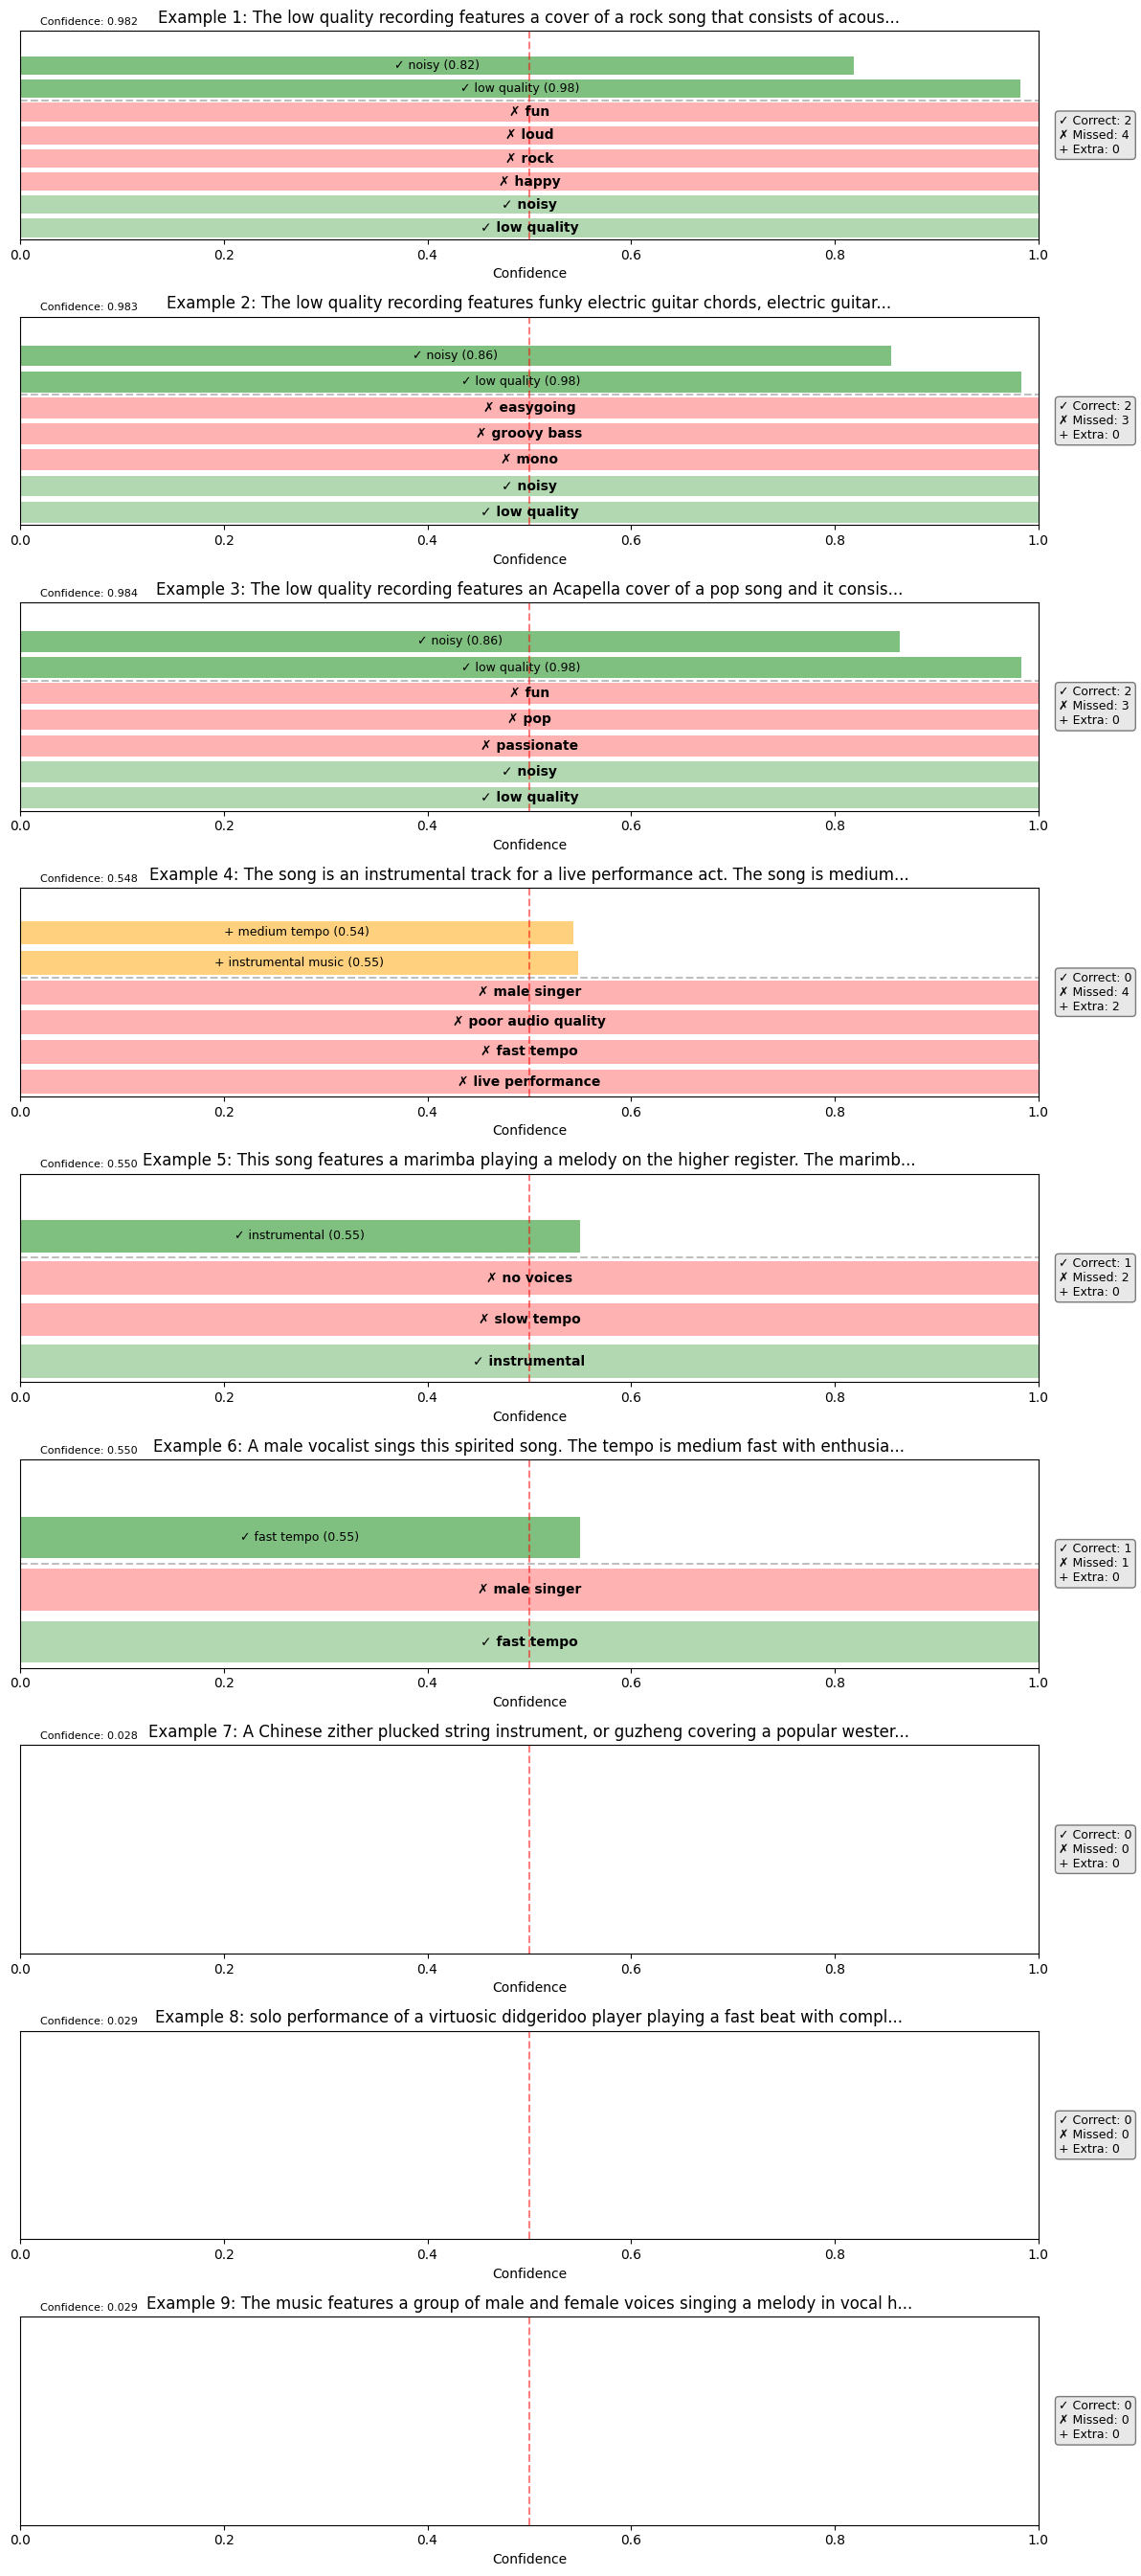

In [ ]:
# Example Predictions Visualization

def visualize_predictions(model, tokenized_dataset, tag_vocab, plots_dir, num_examples):

    try:
        print("Generating predictions for visualization...")
        predictions = trainer.predict(tokenized_dataset)

        pred_logits = predictions.predictions
        labels = predictions.label_ids

        pred_probs = torch.sigmoid(torch.tensor(pred_logits)).numpy()

        try:
            all_texts = list(tokenized_dataset['text'])
        except:
            all_texts = list(tokenized_dataset['text']) if 'text' in tokenized_dataset.column_names else []

        if not all_texts:
            all_texts = [f"Sample {i}" for i in range(len(pred_probs))]

        confidence_scores = np.max(pred_probs, axis=1)
        sorted_indices = np.argsort(confidence_scores)

        total_samples = len(sorted_indices)
        n_per_group = max(1, num_examples // 3)
        indices = []

        if total_samples > 0:
            high_start = max(0, total_samples - n_per_group)
            high_idx = [int(idx) for idx in sorted_indices[high_start:total_samples]]
            indices.extend(high_idx)

            mid_start = max(0, total_samples // 2 - n_per_group // 2)
            mid_end = min(total_samples, mid_start + n_per_group)
            mid_idx = [int(idx) for idx in sorted_indices[mid_start:mid_end]]
            indices.extend(mid_idx)

            low_idx = [int(idx) for idx in sorted_indices[:n_per_group]]
            indices.extend(low_idx)

        indices = list(dict.fromkeys(indices))[:num_examples]

        n_plots = len(indices)
        fig, axes = plt.subplots(n_plots, 1, figsize=(12, max(3, 3*n_plots)))
        if n_plots == 1:
            axes = [axes]

        threshold = 0.5

        for ax_idx, idx in enumerate(indices):
            try:
                if idx < len(all_texts):
                    caption = all_texts[idx]
                    caption = caption[:80] + "..." if len(caption) > 80 else caption
                else:
                    caption = f"Sample {idx}"

                true_tags = [tag_vocab[i] for i, val in enumerate(labels[idx]) if val == 1]
                pred_indices = [i for i, val in enumerate(pred_probs[idx] > threshold) if val]
                pred_tags = [tag_vocab[i] for i in pred_indices]
                pred_confs = [pred_probs[idx][i] for i in pred_indices]

                if pred_tags:
                    sorted_indices = sorted(range(len(pred_tags)), key=lambda i: pred_confs[i], reverse=True)
                    pred_tags = [pred_tags[i] for i in sorted_indices]
                    pred_confs = [pred_confs[i] for i in sorted_indices]

                ax = axes[ax_idx]

                y_offset = 0
                for i, tag in enumerate(true_tags):
                    color = 'green' if tag in pred_tags else 'red'
                    ax.barh(i, 1, color=color, alpha=0.3)
                    ax.text(0.5, i, f'✓ {tag}' if tag in pred_tags else f'✗ {tag}',
                           va='center', ha='center', fontsize=10, fontweight='bold')
                    y_offset = i + 1

                if true_tags and pred_tags:
                    ax.axhline(y=y_offset - 0.5, color='gray', linestyle='--', alpha=0.5)

                for i, (tag, conf) in enumerate(zip(pred_tags, pred_confs)):
                    color = 'green' if tag in true_tags else 'orange'
                    label = '✓' if tag in true_tags else '+'
                    ax.barh(y_offset + i, conf, color=color, alpha=0.5)
                    ax.text(conf/2, y_offset + i,
                           f'{label} {tag} ({conf:.2f})',
                           va='center', ha='center', fontsize=9)

                ax.set_xlim([0, 1])
                ax.set_ylim([-0.5, max(len(true_tags) + len(pred_tags), 1) + 0.5])
                ax.set_xlabel('Confidence')
                ax.set_title(f'Example {ax_idx+1}: {caption}')
                ax.axvline(x=threshold, color='red', linestyle='--', alpha=0.5)
                ax.set_yticks([])

                correct = set(true_tags) & set(pred_tags)
                missed = set(true_tags) - set(pred_tags)
                extra = set(pred_tags) - set(true_tags)

                stats_text = f'✓ Correct: {len(correct)}\n✗ Missed: {len(missed)}\n+ Extra: {len(extra)}'
                ax.text(1.02, 0.5, stats_text, fontsize=9, verticalalignment='center',
                       transform=ax.transAxes, bbox=dict(boxstyle="round", facecolor='lightgray', alpha=0.5))

                ax.text(0.02, 1.02, f'Confidence: {confidence_scores[idx]:.3f}',
                       transform=ax.transAxes, fontsize=8, verticalalignment='bottom')

            except Exception as e:
                print(f"Error processing example {idx}: {e}")
                axes[ax_idx].text(0.5, 0.5, f"Error processing example {idx}",
                                 ha='center', va='center')
                continue

        plt.tight_layout()

        os.makedirs(plots_dir, exist_ok=True)
        plot_path = os.path.join(plots_dir, 'task1_example_predictions.png')
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"Example predictions saved to: {plot_path}")
        # plt.show()
        plt.close(fig)

        return fig

    except Exception as e:
        print(f"Error in visualization: {e}")
        import traceback
        traceback.print_exc()
        return None

visualize_predictions(model, tokenized_datasets['test'], TAG_VOCAB, plots_dir, num_examples=9)

In [ ]:
# Summary Statistics

def generate_summary_table(per_tag_df, test_results, plots_dir):

    summary = {
        'Metric': [
            'Total Tags',
            'Micro-F1',
            'Macro-F1',
            'Micro-Precision',
            'Micro-Recall',
            'Test Accuracy',
            'Tags > 0.7 F1',
            'Tags > 0.5 F1',
            'Tags < 0.3 F1',
            'Best Tag',
            'Best F1',
            'Worst Tag',
            'Worst F1'
        ],
        'Value': [
            len(per_tag_df),
            f"{test_results.get('eval_f1_micro', 0):.4f}",
            f"{per_tag_df['f1'].mean():.4f}",
            f"{test_results.get('eval_precision_micro', 0):.4f}",
            f"{test_results.get('eval_recall_micro', 0):.4f}",
            f"{test_results.get('eval_accuracy', 0):.4f}",
            len(per_tag_df[per_tag_df['f1'] > 0.7]),
            len(per_tag_df[per_tag_df['f1'] > 0.5]),
            len(per_tag_df[per_tag_df['f1'] < 0.3]),
            per_tag_df.loc[per_tag_df['f1'].idxmax(), 'tag'],
            f"{per_tag_df['f1'].max():.4f}",
            per_tag_df.loc[per_tag_df['f1'].idxmin(), 'tag'],
            f"{per_tag_df['f1'].min():.4f}"
        ]
    }

    summary_df = pd.DataFrame(summary)

    summary_df.to_csv(f'{plots_dir}/task1_summary_stats.csv', index=False)
    print("Summary statistics saved to: task1_summary_stats.csv")

    print(summary_df.to_string(index=False))

generate_summary_table(per_tag_df, test_results, plots_dir)

Summary statistics saved to: task1_summary_stats.csv
         Metric       Value
     Total Tags          50
       Micro-F1      0.4777
       Macro-F1      0.2319
Micro-Precision      0.8404
   Micro-Recall      0.3336
  Test Accuracy      0.1773
  Tags > 0.7 F1           5
  Tags > 0.5 F1          14
  Tags < 0.3 F1          34
       Best Tag low quality
        Best F1      0.9624
      Worst Tag  slow tempo
       Worst F1      0.0000


In [ ]:
pip install reportlab Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.8 MB/s eta 0:00:00


In [ ]:
# Save All Plots to PDF

def create_report_pdf(plots_dir):

    from PIL import Image
    import os

    png_files = sorted([f for f in os.listdir(plots_dir) if f.endswith('.png') and f.startswith('task1')])

    if not png_files:
        print("No PNG files found to create PDF")
        return

    try:
        from reportlab.lib.pagesizes import letter
        from reportlab.pdfgen import canvas
        from reportlab.lib.utils import ImageReader

        pdf_path = f'{plots_dir}/task1_visualizations.pdf'
        c = canvas.Canvas(pdf_path, pagesize=letter)
        width, height = letter

        for png_file in png_files:
            img_path = os.path.join(plots_dir, png_file)
            img = ImageReader(img_path)

            title = png_file.replace('task1_', '').replace('.png', '').replace('_', ' ').title()
            c.setFont("Helvetica-Bold", 14)
            c.drawString(50, height - 30, title)

            c.drawImage(img, 50, 50, width=width-100, height=height-100)
            c.showPage()

        c.save()
        print(f"PDF report saved to: {pdf_path}")

    except ImportError:
        print("ReportLab not installed. Skipping PDF creation.")
        print("Install with: pip install reportlab Pillow")

try:
    create_report_pdf(plots_dir)
except Exception as e:
    print(f"Could not create PDF: {e}")

PDF report saved to: /content/CSE425_project/results/plots/task1_visualizations.pdf


In [ ]:
!zip -r /content/CSE425_project.zip /content/CSE425_project

  adding: content/CSE425_project/ (stored 0%)
  adding: content/CSE425_project/models/ (stored 0%)
  adding: content/CSE425_project/models/task1_bert_classifier/ (stored 0%)
  adding: content/CSE425_project/models/task1_bert_classifier/tokenizer_config.json (deflated 43%)
  adding: content/CSE425_project/models/task1_bert_classifier/model.safetensors (deflated 8%)
  adding: content/CSE425_project/models/task1_bert_classifier/training_args.bin (deflated 54%)
  adding: content/CSE425_project/models/task1_bert_classifier/config.json (deflated 70%)
  adding: content/CSE425_project/models/task1_bert_classifier/tokenizer.json (deflated 71%)
  adding: content/CSE425_project/src/ (stored 0%)
  adding: content/CSE425_project/data/ (stored 0%)
  adding: content/CSE425_project/data/processed/ (stored 0%)
  adding: content/CSE425_project/data/processed/mel-spec/ (stored 0%)
  adding: content/CSE425_project/data/processed/graphs/ (stored 0%)
  adding: content/CSE425_project/data/processed/bert_cach